# Implementation

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import sqrtm, null_space

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import UnitaryGate
from qiskit.quantum_info import DensityMatrix
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import DensityMatrix, partial_trace, Statevector

import import_ipynb
from validation_and_helpers import load_run

N = 4
run = load_run(f'data/run_N{N}.npz')
d, D, t_fs = run['d'], run['d'] ** 2, run['t_fs']
res = run['res']
print(f'N = {N},  d = {d},  reference run loaded')

N = 4,  d = 4,  reference run loaded


### `def stinespring_unitary(kraus, d)`
Nehmen wir an, wir haben zwei Kraus-Operatoren $M_0$ und $M_1$. Da $d=3$, sind dies beides $3 \times 3$-Matrizen:
$$M_0 = \begin{pmatrix} a_{11} & a_{12} & a_{13} \\ a_{21} & a_{22} & a_{23} \\ a_{31} & a_{32} & a_{33} \end{pmatrix}, \quad M_1 = \begin{pmatrix} b_{11} & b_{12} & b_{13} \\ b_{21} & b_{22} & b_{23} \\ b_{31} & b_{32} & b_{33} \end{pmatrix} \quad \rightarrow V\vert{}\psi\rangle = \sum_k \vert{}k\rangle_E \otimes M_k\vert{}\psi\rangle = \vert{}0\rangle_E \otimes M_0\vert{}\psi\rangle + \vert{}1\rangle_E \otimes M_1\vert{}\psi\rangle$$

* `n_sys` = $\lceil\log_2(3)\rceil = 2 \rightarrow$ **2 System-Qubits**
* `Dp` = $2^2 = 4 \rightarrow$ **4 Zustände** (aufgefüllte System-Dimension)
* `n_env` = int(np.ceil(np.log2(len(kraus)))) = $\lceil\log_2(2)\rceil = 1 \rightarrow$ **1 Umgebungs-Qubit**
* `Kp` = $2^1 = 2 \rightarrow$ **2 Zustände** (Umgebungs-Dimension)

Der Quantenschaltkreis benötigt also insgesamt $2 + 1 = 3$ Qubits, was einen Gesamtraum der Dimension $2^3 = 8$ aufspannt. Daher initialisieren wir eine $8 \times 4$-Matrix:
* `V = np.zeros((Kp * Dp, Dp), complex)` = `np.zeros((2 * 4, 4), complex)` = (8,4)

In `V[k * Dp:k * Dp + d, :d] = M` wird die Tensorprodukt-Struktur $\vert{}k\rangle_E \otimes \tilde{M}_k$ (mit den implizit durch Nullen auf $4 \times 4$ aufgefüllten Matrizen) physisch in das Array geschrieben:

$$V = \big( \vert 0 \rangle_E \otimes \tilde{M}_0 \big) + \big( \vert 1 \rangle_E \otimes \tilde{M}_1 \big) = \begin{pmatrix} \tilde{M}_0 \\ \mathbf{0}_{4\times4} \end{pmatrix} + \begin{pmatrix} \mathbf{0}_{4\times4} \\ \tilde{M}_1 \end{pmatrix} = \begin{pmatrix} \tilde{M}_0 \\ \tilde{M}_1 \end{pmatrix}_{8\times4} = \begin{pmatrix} a_{11} & a_{12} & a_{13} & 0 \\ a_{21} & a_{22} & a_{23} & 0 \\ a_{31} & a_{32} & a_{33} & 0 \\ 0 & 0 & 0 & 0 \\ b_{11} & b_{12} & b_{13} & 0 \\ b_{21} & b_{22} & b_{23} & 0 \\ b_{31} & b_{32} & b_{33} & 0 \\ 0 & 0 & 0 & 0 \end{pmatrix} \begin{array}{l} \left.\begin{array}{l} \text{System } \vert{}0\rangle \\ \text{System } \vert{}1\rangle \\ \text{System } \vert{}2\rangle \\ \text{System Padding } \vert{}3\rangle \end{array}\right\} \text{Env } \vert{}0\rangle \\ \left.\begin{array}{l} \text{System } \vert{}0\rangle \\ \text{System } \vert{}1\rangle \\ \text{System } \vert{}2\rangle \\ \text{System Padding } \vert{}3\rangle \end{array}\right\} \text{Env } \vert{}1\rangle \end{array} = \begin{pmatrix} M_0 & \begin{matrix} 0 \\ 0 \\ 0 \end{matrix} \\ \begin{matrix} 0 & 0 & 0 \end{matrix} & 0 \\ M_1 & \begin{matrix} 0 \\ 0 \\ 0 \end{matrix} \\ \begin{matrix} 0 & 0 & 0 \end{matrix} & 0 \end{pmatrix}$$

Wir schneiden die letzte Spalte (die unphysikalische Padding-Spalte) ab. `iso` ist nun eine $8 \times 3$-Matrix:
$$\text{iso} = \begin{pmatrix} a_{11} & a_{12} & a_{13} \\ a_{21} & a_{22} & a_{23} \\ a_{31} & a_{32} & a_{33} \\ 0 & 0 & 0 \\ b_{11} & b_{12} & b_{13} \\ b_{21} & b_{22} & b_{23} \\ b_{31} & b_{32} & b_{33} \\ 0 & 0 & 0 \end{pmatrix} =  \begin{pmatrix}  M_0 \\  \begin{matrix} 0 & 0 & 0 \end{matrix} \\  M_1 \\  \begin{matrix} 0 & 0 & 0 \end{matrix}  \end{pmatrix}$$
Diese Matrix ist eine perfekte Isometrie ($\text{iso}^\dagger \cdot \text{iso} = \mathbb{1}_3$), weil die Kraus-Operatoren per Definition $\sum M_k^\dagger M_k = \mathbb{1}$ erfüllen.

Damit ein Quantencomputer die Operation ausführen kann, muss sie reversibel (unitär) sein. Aktuell bildet `iso` einen 3-dimensionalen Raum isometrisch in einen 8-dimensionalen Raum ab. Wir brauchen aber eine quadratische $8 \times 8$-Matrix.
- `null_space(iso.conj().T)`: Sucht das orthogonale Komplement zu unseren 3 Spaltenvektoren. Da wir im 8-dimensionalen Raum sind, findet diese Funktion exakt $8 - 3 = 5$ weitere orthonormale Vektoren (eine $8 \times 5$-Matrix).
- `np.hstack`: Klebt unsere $8 \times 3$-Isometrie und die gefundenen $8 \times 5$-Vektoren nebeneinander.

$$U = \left( \begin{array}{ccc|ccccc} a_{11} & a_{12} & a_{13} & n_{1,1} & n_{1,2} & n_{1,3} & n_{1,4} & n_{1,5} \\ a_{21} & a_{22} & a_{23} & n_{2,1} & n_{2,2} & n_{2,3} & n_{2,4} & n_{2,5} \\ a_{31} & a_{32} & a_{33} & n_{3,1} & n_{3,2} & n_{3,3} & n_{3,4} & n_{3,5} \\ 0 & 0 & 0 & n_{4,1} & n_{4,2} & n_{4,3} & n_{4,4} & n_{4,5} \\ b_{11} & b_{12} & b_{13} & n_{5,1} & n_{5,2} & n_{5,3} & n_{5,4} & n_{5,5} \\ b_{21} & b_{22} & b_{23} & n_{6,1} & n_{6,2} & n_{6,3} & n_{6,4} & n_{6,5} \\ b_{31} & b_{32} & b_{33} & n_{7,1} & n_{7,2} & n_{7,3} & n_{7,4} & n_{7,5} \\ 0 & 0 & 0 & n_{8,1} & n_{8,2} & n_{8,3} & n_{8,4} & n_{8,5} \end{array} \right) = \begin{pmatrix} \text{iso} & \Bigg\vert & N \end{pmatrix}$$

In [2]:
def stinespring_unitary(kraus, d):  # Konstruiert U mit liste aus Krausoperatoren, d ist dim des Systems
    """U on (env (x) sys) with U(|0>_env (x) |psi>) = sum_k M_k|psi>|k>.

    The composite index is env*2^n_sys + sys, which is Qiskit's ordering when the
    system qubits are appended first (they are the low bits)."""
    n_sys = int(np.ceil(np.log2(d)))   # d=9 -> n_sys=4, Dp=16
    Dp = 2 ** n_sys
    n_env = int(np.ceil(np.log2(len(kraus)))) # Wenn es z.B. 3 Kraus-Operatoren gibt, braucht man 2 Qubits
    Kp = 2 ** n_env

    V = np.zeros((Kp * Dp, Dp), complex)  # Initialisiert die Isometrie-Matrix V. Die Dimension ist (Gesamtraum * Systemraum).
    for k, M in enumerate(kraus):
        V[k * Dp:k * Dp + d, :d] = M      # Hier passiert die eigentliche Dilation |psi> = sum_k |k>_E \otimes M_k|psi>.
    iso = V[:, :d]                                  # Schneidet die Matrix auf den rein physikalischen System-Unterraum ab
    U = np.hstack([iso, null_space(iso.conj().T)])  # Erweitert isometrische Matrix zu einer quadratischen, unitären Matrix U
    return U, n_sys, Dp, n_env

In [3]:
def propagate_stinespring_shots(kraus, d, n_steps, shots=4096):
    """
    Für jeden Zeitschritt einen eigenen Schaltkreis + Shots.
    Gibt Populationsmatrix (n_steps+1, d) zurück.
    """
    U, n_sys, Dp, n_env = stinespring_unitary(kraus, d)
    gate = UnitaryGate(U, label='U')

    # Startzustand |0...0>
    psi0 = np.zeros(Dp, dtype=complex)
    psi0[0] = 1.0

    sim = AerSimulator()
    pops = np.zeros((n_steps + 1, d))

    # t = 0
    pops[0, :d] = np.abs(psi0[:d])**2

    for t in range(1, n_steps + 1):
        print(f"Zeitschritt {t}/{n_steps}", end='\r')

        qc = QuantumCircuit(n_sys + n_env, n_sys)
        qc.initialize(psi0, range(n_sys))

        # t-mal (U + Reset)
        for _ in range(t):
            qc.append(gate, range(n_sys + n_env))
            qc.reset(range(n_sys, n_sys + n_env))

        qc.measure(range(n_sys), range(n_sys))

        result = sim.run(transpile(qc, sim), shots=shots).result()
        counts = result.get_counts()

        for bitstring, count in counts.items():
            idx = int(bitstring, 2) 
            if idx < d:
                pops[t, idx] += count / shots

        if t==10:
            return_qc = qc

    print()
    return pops, return_qc, dict(n_sys=n_sys, n_env=n_env, n_qubits=n_sys + n_env)

https://github.com/Qiskit/qiskit-aer/blob/stable/0.17/qiskit_aer/library/set_instructions/set_density_matrix.py#L48-L75

In [ ]:
def propagate_stinespring_density_matrix(kraus, d, n_steps, rho0=None):    # Baut den Qiskit-Schaltkreis und führt die eigentliche Dynamik aus.
    """ONE circuit, T = n_steps*dt, deterministic. Returns (pops, circuit, info).

    Nothing is measured and nothing is re-prepared: each step applies the same
    unitary and resets the environment (= traces it out)."""
    U, n_sys, Dp, n_env = stinespring_unitary(kraus, d)

    # Falls kein Startzustand übergeben wird, startet das System im reinen Zustand |0><0|.
    if rho0 is None:    
        rho0 = np.zeros((Dp, Dp), complex)
        rho0[0, 0] = 1.0

    # Weist den Qubits im Schaltkreis Rollen zu: 
    sys_q = list(range(n_sys))                  # Die ersten Indizes (z.B. 0 und 1) sind das System, 
    env_q = list(range(n_sys, n_sys + n_env))   # die darauffolgenden (z.B. 2, 3, 4) das Environment.

    # Initialisiert die Dichtematrix des Environments als reinen Zustand |0...0><0...0|.
    env0 = np.zeros((2 ** n_env, 2 ** n_env), complex)
    env0[0, 0] = 1.0

    qc = QuantumCircuit(n_sys + n_env)                          # Erstellt den Qiskit-Schaltkreis mit der Gesamtanzahl an Qubits.
    qc.set_density_matrix(DensityMatrix(np.kron(env0, rho0)))   # Weist dem Simulator den totalen Anfangszustand rho_B (x) rho_S zu
    qc.save_density_matrix(sys_q, label='t0')                   # Speichert den Systemzustand bei t=0  im Simulator ab (ohne Messung).
    gate = UnitaryGate(U, label='U')                  # Verpackt die NumPy-Matrix $U$ in ein anwendbares Qiskit-Gatter.

    for t in range(1, n_steps + 1):                    # Startet die zeitliche Evolutions-Schleife für n Schritte.
        qc.append(gate, sys_q + env_q)                 # Wendet das Stinespring-Gatter auf die System- und Environment-Qubits an.
        qc.reset(env_q)                                # Env wird auf |0> zurückgesetzt und bildet die partielle Spur Tr_E.
        qc.save_density_matrix(sys_q, label=f't{t}')   # Speichert aktuelle reduzierte Dichtematrix des Systems für Endresultat ab.

    data = AerSimulator(method='density_matrix').run(qc).result().data()    # Führt Schaltkreis auf Qiskits Dichtematrix-Simulator aus.
    rho = np.array([np.asarray(data[f't{t}']) for t in range(n_steps + 1)]) # Sammelt alle über save_density_matrix gespeicherten Matrizen
    pops = np.real(np.diagonal(rho, axis1=1, axis2=2))[:, :d]               # Extrahiert die Diagonalelemente für jeden Zeitschritt.

    return pops, qc, dict(rho=rho, n_sys=n_sys, n_env=n_env, n_qubits=n_sys + n_env, p_success=1.0)

In [5]:
n_steps = len(t_fs) - 1

pops_shots, qc_A, info_A = propagate_stinespring_shots(
    res['Lindblad']['kraus_dt'], d, n_steps
)

Zeitschritt 100/100


In [6]:
pops_density_matrix, _, _ = propagate_stinespring_density_matrix(
    res['Lindblad']['kraus_dt'], d, n_steps
)

Number of System Qubits: 2
Number of environment Qubits: 4
Number of Kraus operators: 16


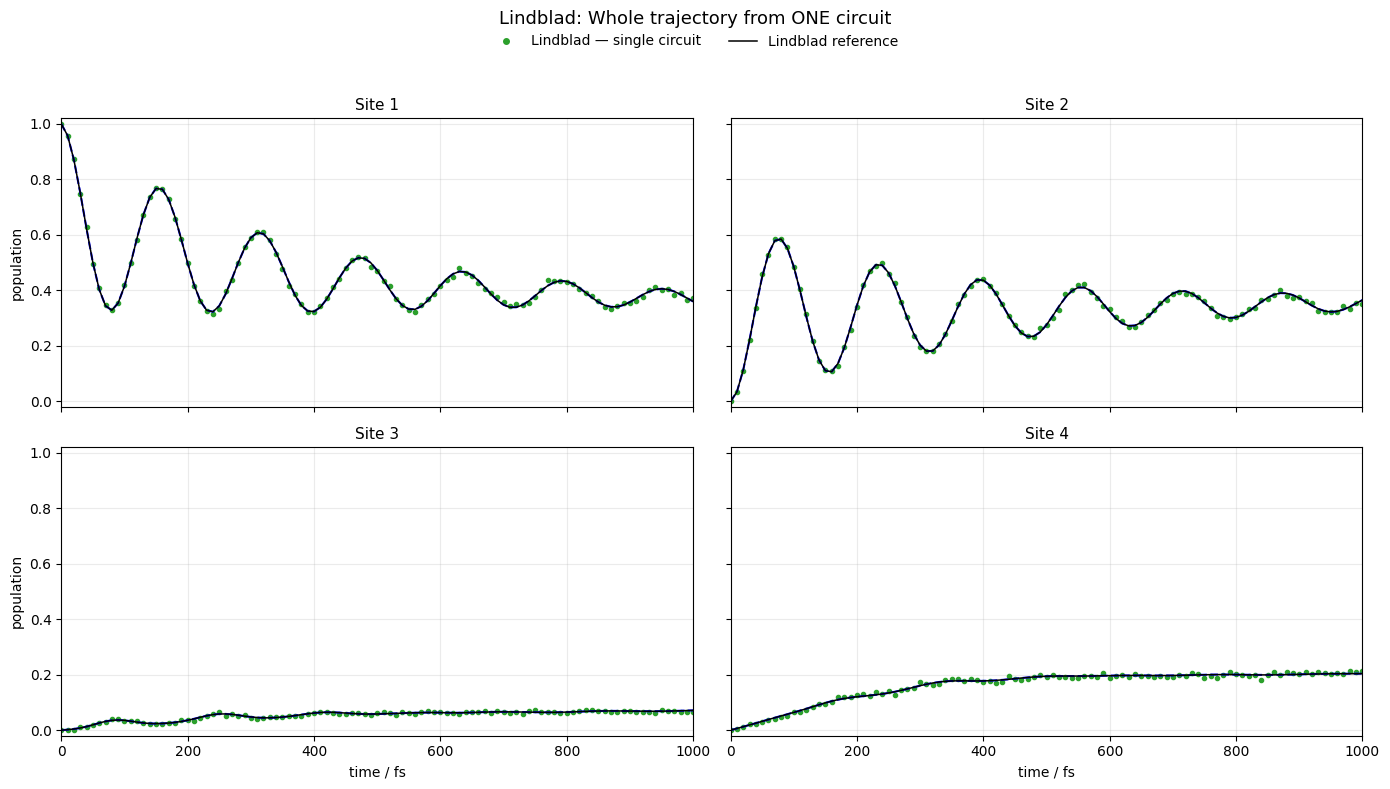

In [7]:
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt

print("Number of System Qubits:", info_A['n_sys'])
print("Number of environment Qubits:", info_A['n_env'])
print("Number of Kraus operators:", len(res['Lindblad']['kraus_dt']))

col_lindblad = '#2ca02c'
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)

for site, ax in enumerate(axes.flat):
    # Quantenschaltkreis-Ergebnis: marker='o' statt ls='o'
    ax.plot(t_fs, pops_shots[:, site], color=col_lindblad, marker='o', ls='none', markersize=3, label='circuit')
    ax.plot(t_fs, pops_density_matrix[:, site], color='b', ls='--', markersize=3, label='density matrix')
    
    # Exakte klassische Lindblad-Referenz
    ax.plot(t_fs, res['Lindblad']['pops'][:, site], color='k', ls='-', lw=1.1)

    ax.set_title(f'Site {site + 1}', fontsize=11)
    ax.set_xlim(0, t_fs[-1])
    ax.set_ylim(-0.02, 1.02)
    ax.grid(alpha=0.25)
    if site >= 2:
        ax.set_xlabel('time / fs')
    if site % 2 == 0:
        ax.set_ylabel('population')

# Legende
handles = [
    Line2D([], [], color=col_lindblad, marker='o', ls='none', markersize=4, label='Lindblad — single circuit'),
    Line2D([], [], color='k', ls='-', lw=1.1, label='Lindblad reference')
]
fig.legend(handles=handles, loc='upper center', ncol=2, frameon=False, fontsize=10,
           bbox_to_anchor=(0.5, 0.965))

fig.suptitle('Lindblad: Whole trajectory from ONE circuit', fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.93])

fig.savefig(f'pictures/single_grid_lindblad_N{N}.png', dpi=200)
plt.show()

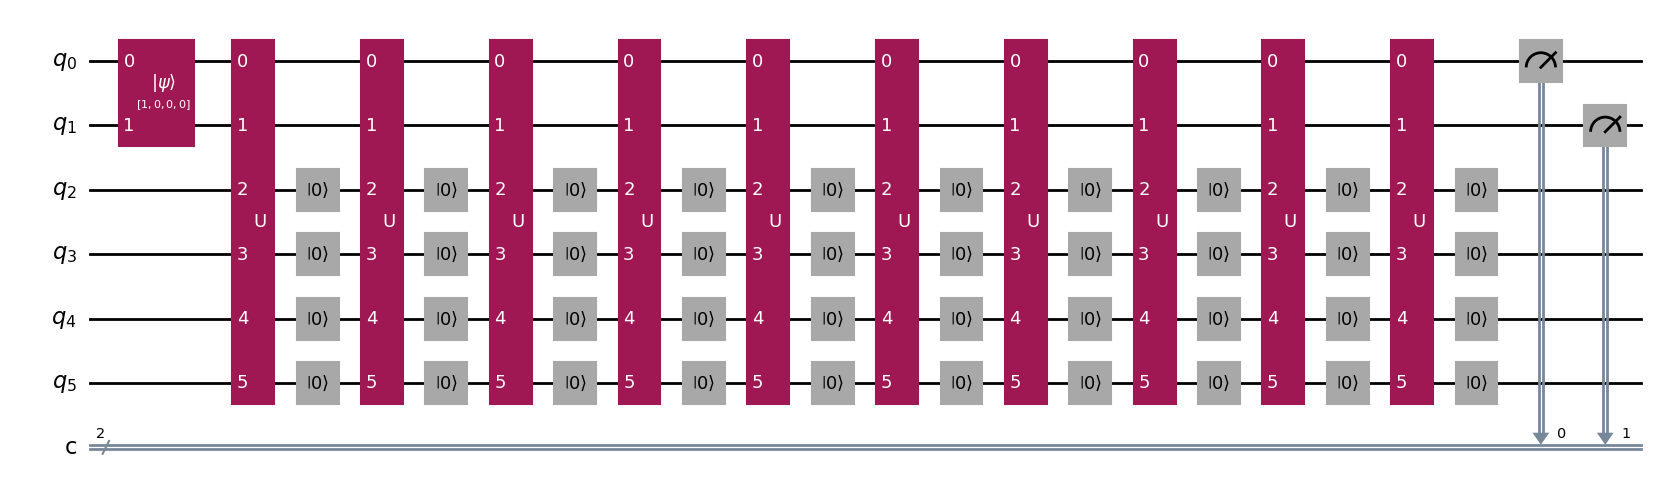

In [8]:
qc_A.draw(output='mpl')